# Variational Mode Decomposition (VMD)

> **Original paper**: Dragomiretskiy, K. & Zosso, D. (2014). *Variational Mode Decomposition*. IEEE Transactions on Signal Processing, 62(3), 531–544.
> DOI: [10.1109/TSP.2013.2288675](https://doi.org/10.1109/TSP.2013.2288675)

This notebook introduces the historical significance and mathematical foundations of VMD, and reproduces classic numerical experiments from the paper using PySDKit.

---

## Contents

1. Historical background and why VMD matters
2. From IMFs to a narrow-band prior
3. Variational model and ADMM solution
4. Wiener-filter interpretation
5. PySDKit API overview
6. Experiment 1: Pure-tone reconstruction
7. Experiment 2: Two-tone separation
8. Experiment 3: Noisy tri-harmonic signal
9. Experiment 4: Over- / under-segmentation
10. Experiment 5: Frequency-modulated / non-stationary signals
11. Summary

## 1. Historical background and why VMD matters

### 1.1 The EMD era: empirically successful, theoretically incomplete

Around 1998, Huang et al. introduced **Empirical Mode Decomposition (EMD)**, which became a widely used tool for adaptive time–frequency analysis. EMD recursively separates “modes” by locating local extrema, interpolating envelopes, and sifting. It has been applied extensively in audio, climate science, and biomedical engineering.

However, as Dragomiretskiy & Zosso emphasize in the introduction, EMD has fundamental limitations:

- **High sensitivity to noise and sampling**;
- Strong dependence on heuristic details such as extrema detection, envelope interpolation, and stopping criteria;
- **Lack of a rigorous mathematical theory** — the procedure is an algorithmic recipe rather than a provable optimization problem.

The paper states:

> *“The lack of mathematical theory and the aforementioned degrees of freedom reducing the algorithm’s robustness all leave room for theoretical development…”*

Later variants (Ensemble EMD, empirical wavelets, synchrosqueezing, recursive variational decompositions, etc.) improved robustness in places, but many still retained EMD’s recursive sifting skeleton or only partially introduced mathematical constraints.

### 1.2 The paradigm shift of VMD

VMD’s key contribution is to reformulate signal decomposition as a **constrained variational optimization problem that extracts modes concurrently**.

| Aspect | Empirical methods (e.g. EMD) | VMD |
|--------|------------------------------|-----|
| Problem form | Heuristic recursive sifting | **Constrained variational optimization** |
| Mode extraction | One-by-one, recursive | **Joint / concurrent recovery** |
| Theoretical basis | Empirical rules | Hilbert transform + bandwidth prior + ADMM |
| Link to filtering | Implicit, hard to analyze | **Explicit multi-band Wiener filtering** |
| Noise robustness | Often weak | Naturally handled via a quadratic fidelity term |

This is why VMD is a milestone in signal decomposition: it offers a framework that is theoretically grounded, algorithmically clear, and experimentally more robust.


## 2. From IMFs to a narrow-band prior

### 2.1 Intrinsic Mode Functions (IMFs)

In the modern definition, an IMF is an AM–FM signal (paper Definition 1):

$$
u_k(t) = A_k(t)\,\cos\big(\phi_k(t)\big),
$$

where the phase $\phi_k(t)$ is non-decreasing, $A_k(t)\ge 0$, and both the envelope and the instantaneous frequency vary much more slowly than the phase. The instantaneous frequency is

$$
\omega_k(t) = \frac{\mathrm{d}\phi_k(t)}{\mathrm{d}t}.
$$

### 2.2 Practical bandwidth (Carson’s rule)

If the carrier is $\omega_k$, the maximum instantaneous-frequency deviation is $\Delta\omega$, the rate of that deviation is $\dot\omega$, and the highest envelope frequency is $B_{\mathrm{AM}}$, then the practical bandwidth can be estimated as (paper Eqs. (2)–(3))

$$
B_{\mathrm{FM}} \approx \Delta\omega + \dot\omega, \qquad
B_{\mathrm{IMF}} \approx 2\big(B_{\mathrm{FM}} + B_{\mathrm{AM}}\big).
$$

Thus, admissible IMFs are naturally **band-limited**. VMD does not explicitly construct envelopes and phases; instead it uses **narrow-bandness** directly as an optimization prior.


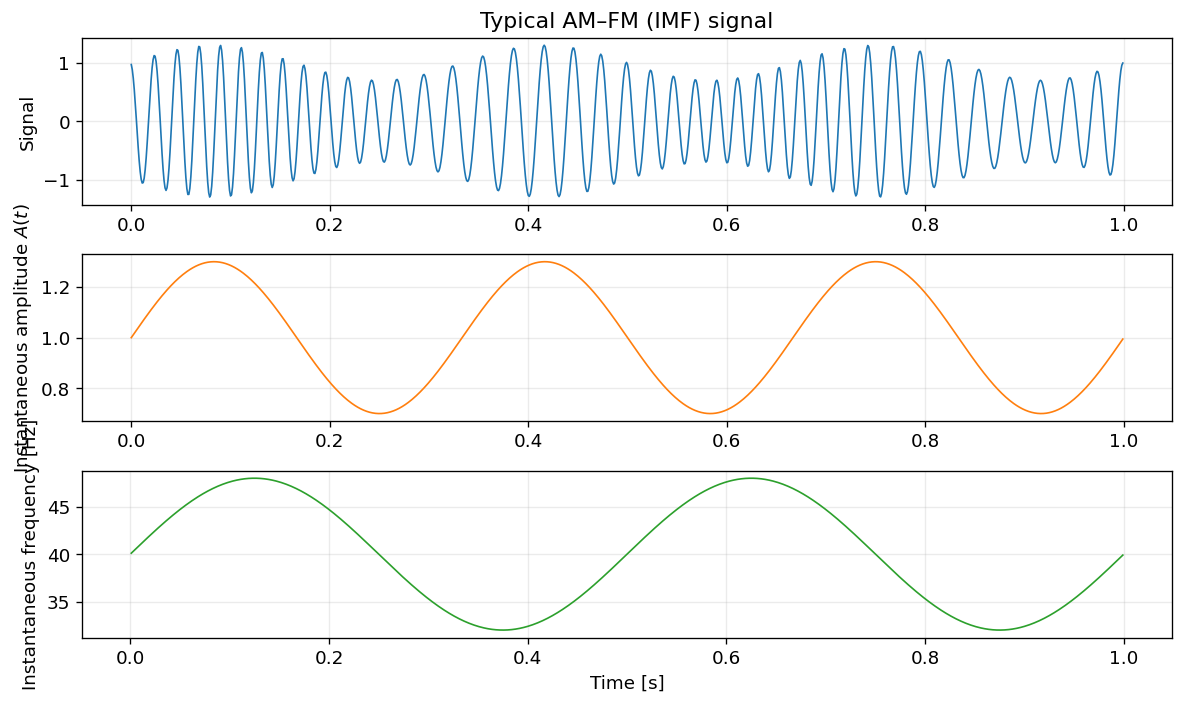

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

from pysdkit import VMD, EMD
from pysdkit.data import test_emd
from pysdkit.plot import plot_IMFs, plot_IMFs_amplitude_spectra

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)


def relative_error(ref, est):
    ref = np.asarray(ref, dtype=float).ravel()
    est = np.asarray(est, dtype=float).ravel()
    n = min(ref.size, est.size)
    return np.linalg.norm(est[:n] - ref[:n]) / (np.linalg.norm(ref[:n]) + 1e-16)


# Illustrate the narrow-band intuition with a simple AM–FM signal
fs = 1000.0
t = np.arange(0, 1.0, 1.0 / fs)
am = 1.0 + 0.3 * np.sin(2 * np.pi * 3 * t)
fm = 40 + 8 * np.sin(2 * np.pi * 2 * t)
sig = am * np.cos(2 * np.pi * np.cumsum(fm) / fs)

analytic = hilbert(sig)
inst_amp = np.abs(analytic)
inst_freq = np.diff(np.unwrap(np.angle(analytic))) * fs / (2 * np.pi)

fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=False)
axs[0].plot(t, sig, lw=1.0)
axs[0].set_ylabel("Signal")
axs[0].set_title("Typical AM–FM (IMF) signal")

axs[1].plot(t, inst_amp, color="C1", lw=1.0)
axs[1].set_ylabel(r"Instantaneous amplitude $A(t)$")

axs[2].plot(t[1:], inst_freq, color="C2", lw=1.0)
axs[2].set_ylabel("Instantaneous frequency [Hz]")
axs[2].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()


## 3. Variational model and ADMM solution

### 3.1 Three steps to build the bandwidth cost

For each candidate mode $u_k$, VMD estimates bandwidth as follows (paper Section III):

1. Apply the **Hilbert transform** to obtain the analytic signal (one-sided spectrum);
2. Mix with a complex exponential at the current center frequency $\omega_k$ to shift the spectrum to **baseband**;
3. Measure bandwidth by the $L^2$ norm of the gradient of the demodulated signal (Gaussian smoothness).

This yields the constrained variational problem (paper Eq. (14)):

$$
\min_{\{u_k\},\{\omega_k\}}
\left\{
\sum_{k=1}^{K}
\left\|
\partial_t
\Big[
\big(\delta(t)+\tfrac{j}{\pi t}\big)*u_k(t)
\Big]
e^{-j\omega_k t}
\right\|_2^2
\right\}
\quad
\text{s.t.}\quad
\sum_{k=1}^{K} u_k = f.
$$

Intuitively: **reconstruct the input $f$ while making each demodulated mode as smooth as possible** (i.e., spectrally compact).

### 3.2 Augmented Lagrangian

Introducing a quadratic penalty and a Lagrange multiplier $\lambda$ gives the augmented Lagrangian (paper Eq. (15)):

$$
\begin{aligned}
\mathcal{L}(\{u_k\},\{\omega_k\},\lambda)
&=
\alpha\sum_{k}
\left\|
\partial_t
\Big[
\big(\delta+\tfrac{j}{\pi t}\big)*u_k
\Big]
e^{-j\omega_k t}
\right\|_2^2 \\
&\quad +
\Big\|
f - \sum_k u_k
\Big\|_2^2
+
\Big\langle
\lambda,\;
f - \sum_k u_k
\Big\rangle.
\end{aligned}
$$

Here $\alpha$ controls bandwidth compactness (larger $\Rightarrow$ narrower modes); the quadratic term encourages reconstruction fidelity; $\lambda$ can **strictly** enforce the constraint when needed.

### 3.3 ADMM iteration (Algorithms 1 / 2)

The alternating direction method of multipliers solves the problem efficiently in the Fourier domain. The core updates are:

**(1) Mode-spectrum update — Wiener filtering (paper Eq. (27))**

$$
\hat u_k^{n+1}(\omega)
=
\frac{
\hat f(\omega) - \sum_{i\neq k}\hat u_i(\omega) + \hat\lambda(\omega)/2
}{
1 + 2\alpha\,(\omega-\omega_k)^2
}.
$$

**(2) Center-frequency update — center of gravity of the power spectrum (paper Eq. (28))**

$$
\omega_k^{n+1}
=
\frac{
\int_0^\infty \omega\,|\hat u_k(\omega)|^2\,\mathrm{d}\omega
}{
\int_0^\infty |\hat u_k(\omega)|^2\,\mathrm{d}\omega
}.
$$

**(3) Dual ascent (paper Eq. (29))**

$$
\hat\lambda^{n+1}
=
\hat\lambda^{n}
+
\tau\Big(\hat f - \sum_k \hat u_k^{n+1}\Big).
$$

Convergence is typically declared when the relative change of mode spectra between iterations falls below a tolerance $\varepsilon$.

> **Implementation note**: PySDKit and many open-source codes write the denominator as $1+\alpha(\omega-\omega_k)^2$, absorbing the factor $2$ into the scaling of $\alpha$. With consistent parameter tuning the two forms are equivalent.


## 4. Wiener-filter interpretation

Classical 1-D Wiener denoising has the frequency-domain gain

$$
\hat u(\omega)
=
\frac{1}{1+2\alpha\omega^2}\,\hat f(\omega),
$$

corresponding to a low-pass prior. The VMD mode update generalizes this filter to **multiple adaptive passbands centered at $\omega_k$**:

$$
\hat u_k(\omega)
=
\frac{1}{1+2\alpha(\omega-\omega_k)^2}
\Big(
\hat f(\omega)-\sum_{i\neq k}\hat u_i(\omega)+\hat\lambda(\omega)/2
\Big).
$$

Thus VMD can be viewed as:

> **a multi-band, adaptive-center Wiener filter bank + a reconstruction constraint**.

This also explains why, under strong noise, setting $\tau=0$ (disabling the Lagrange-multiplier update) is often preferable: only the quadratic fidelity term remains, which tends to suppress noise rather than force exact reconstruction of the noisy observation.


## 5. PySDKit API overview

Object-oriented interface:

    from pysdkit import VMD

    vmd = VMD(alpha=2000, K=3, tau=0.0, DC=False, init="uniform", tol=1e-7)
    modes = vmd.fit_transform(signal)                 # shape: (K, N)
    modes, u_hat, omega = vmd.fit_transform(signal, return_all=True)

| Parameter | Meaning |
|-----------|---------|
| `K` | Number of modes to recover |
| `alpha` | Bandwidth penalty (larger → narrower bands) |
| `tau` | Dual-ascent step; often `0` under strong noise |
| `DC` | Keep the first mode at zero frequency |
| `init` | Center-frequency initialization: `uniform` / `random` / `zero` |
| `tol` | Convergence tolerance |


In [2]:
# Quick sanity check
t0, s0 = test_emd(duration=1.0, sampling_rate=500, noise_level=0.05)
vmd0 = VMD(alpha=2000, K=3, tau=0.0, tol=1e-6, max_iter=300)
imfs0 = vmd0.fit_transform(s0)
print("modes shape:", imfs0.shape)
re0 = relative_error(s0[: imfs0.shape[1]], imfs0.sum(0))
print(f"relative recon. error: {re0:.4e}")

modes shape: (3, 500)
relative recon. error: 7.8518e-02


## 6. Experiment 1: Pure-tone reconstruction

Section IV-A of the paper notes that a pure harmonic should be recovered essentially exactly. For EMD, the relative error grows roughly quadratically with frequency; for VMD it is largely frequency-independent and is controlled by the convergence tolerance $\varepsilon$.

The relative error is defined as (paper Eq. (30))

$$
E_{\mathrm{rel}}
=
\frac{\|u-\tilde u\|_2}{\|u\|_2}.
$$


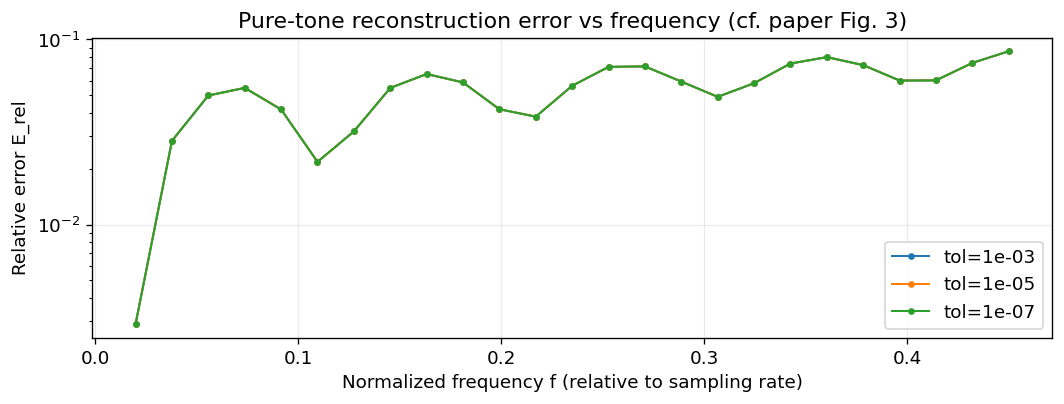

In [ ]:
N = 1000
freqs = np.linspace(0.02, 0.45, 25)  # normalized frequency (relative to sampling rate)
tols = [1e-3, 1e-5, 1e-7]
errs = {tol: [] for tol in tols}

for f0 in freqs:
    tone = np.cos(2 * np.pi * f0 * np.arange(N))
    for tol in tols:
        vmd = VMD(alpha=2000, K=1, tau=0.0, tol=tol, max_iter=400)
        u = vmd.fit_transform(tone)[0]
        errs[tol].append(relative_error(tone, u))

fig, ax = plt.subplots(figsize=(9, 3.5))
for tol in tols:
    ax.semilogy(freqs, errs[tol], "o-", ms=3, lw=1.2, label=f"tol={tol:.0e}")
ax.set_xlabel("Normalized frequency f (relative to sampling rate)")
ax.set_ylabel("Relative error E_rel")
ax.set_title("Pure-tone reconstruction error vs frequency (cf. paper Fig. 3)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Experiment 2: Two-tone separation

The input is a sum of two pure harmonics (paper Eq. (31)):

$$
f(t)=a_1\cos(2\pi f_1 t)+a_2\cos(2\pi f_2 t).
$$

EMD exhibits large confusion regions when the frequencies are close; VMD typically separates the tones stably away from the Nyquist frequency.


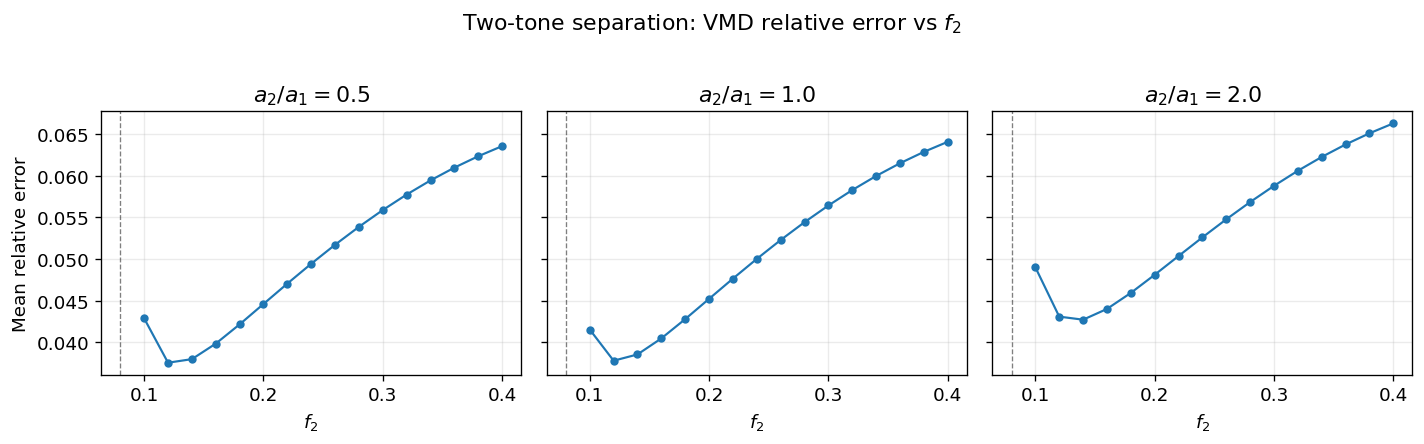

In [ ]:
N = 1000
n = np.arange(N)
f1 = 0.08
f2_list = np.linspace(0.10, 0.40, 16)
amp_ratios = [0.5, 1.0, 2.0]

fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, ratio in zip(axs, amp_ratios):
    a1, a2 = 1.0, ratio
    re_map = []
    for f2 in f2_list:
        sig = a1 * np.cos(2 * np.pi * f1 * n) + a2 * np.cos(2 * np.pi * f2 * n)
        vmd = VMD(alpha=5000, K=2, tau=0.0, tol=1e-7, max_iter=400)
        modes = vmd.fit_transform(sig)
        # Match modes to the two ground-truth tones by spectral peak location
        specs = [np.abs(np.fft.rfft(m)) for m in modes]
        peaks = [np.argmax(s) / N for s in specs]
        order = np.argsort(peaks)
        modes = modes[order]
        e1 = relative_error(a1 * np.cos(2 * np.pi * f1 * n), modes[0])
        e2 = relative_error(a2 * np.cos(2 * np.pi * f2 * n), modes[1])
        re_map.append(0.5 * (e1 + e2))
    ax.plot(f2_list, re_map, "o-", lw=1.3, ms=4)
    ax.axvline(f1, color="k", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(rf"$a_2/a_1={ratio}$")
    ax.set_xlabel(r"$f_2$")
axs[0].set_ylabel("Mean relative error")
fig.suptitle(r"Two-tone separation: VMD relative error vs $f_2$", y=1.02)
plt.tight_layout()
plt.show()

Estimated normalized center frequencies: [0.024 0.096]
Approx. Hz: [24. 96.]


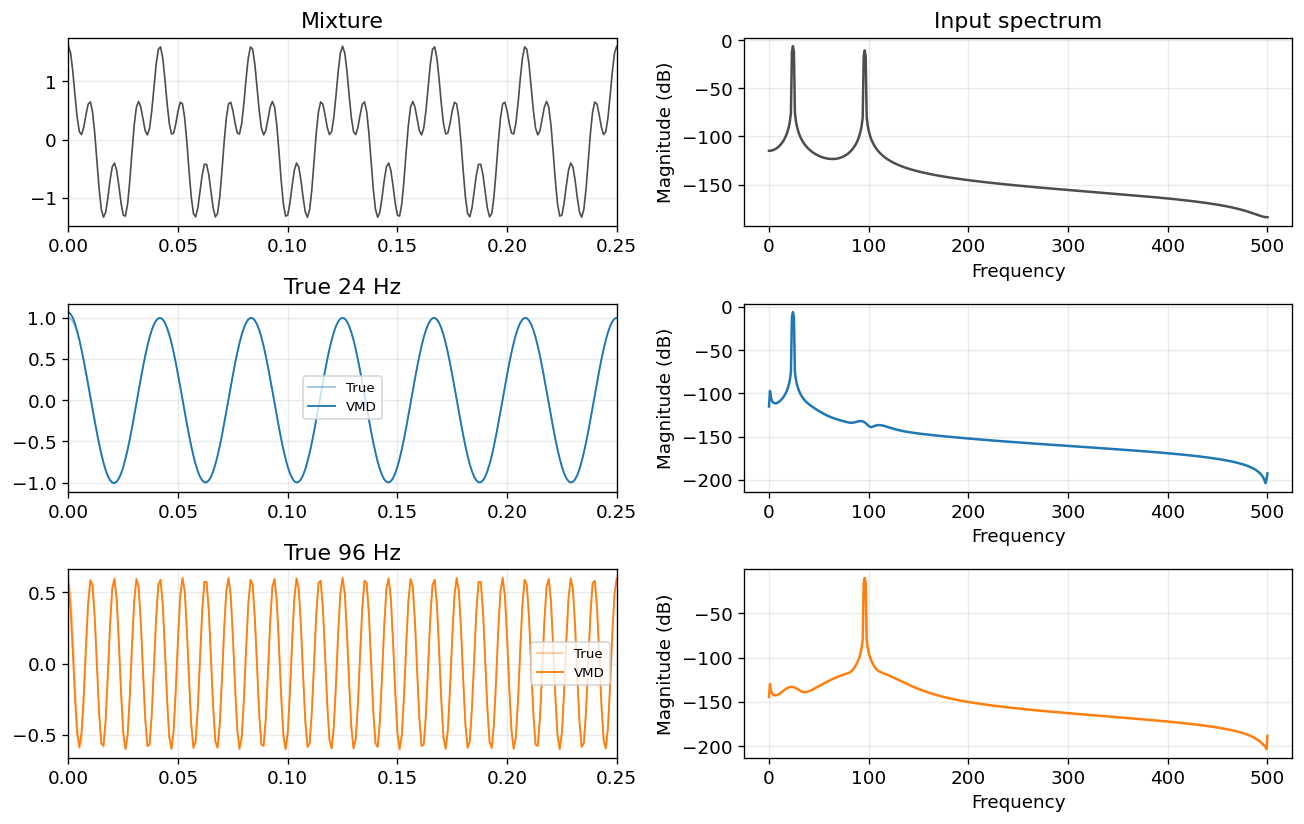

mode0 RE = 0.008418452431093426
mode1 RE = 0.025892749802522666


In [5]:
# Visualize one concrete two-tone example
fs = 1000.0
t = np.arange(0, 1.0, 1 / fs)
s1 = 1.0 * np.cos(2 * np.pi * 24 * t)
s2 = 0.6 * np.cos(2 * np.pi * 96 * t)
signal = s1 + s2

vmd = VMD(alpha=2000, K=2, tau=0.0, tol=1e-7, max_iter=500)
modes, u_hat, omega = vmd.fit_transform(signal, return_all=True)

print("Estimated normalized center frequencies:", np.round(omega[-1], 4))
print("Approx. Hz:", np.round(omega[-1] * fs, 2))

fig, axs = plt.subplots(3, 2, figsize=(11, 7))
axs[0, 0].plot(t, signal, color="0.3", lw=1.0)
axs[0, 0].set_title("Mixture")
axs[0, 1].magnitude_spectrum(signal, Fs=fs, scale="dB", color="0.3")
axs[0, 1].set_title("Input spectrum")

comps = [(s1, "True 24 Hz", "C0"), (s2, "True 96 Hz", "C1")]
for i, (comp, name, c) in enumerate(comps):
    axs[i + 1, 0].plot(t, comp, color=c, lw=1.0, alpha=0.45, label="True")
    axs[i + 1, 0].plot(t, modes[i], color=c, lw=1.1, label="VMD")
    axs[i + 1, 0].set_title(name)
    axs[i + 1, 0].legend(fontsize=8)
    axs[i + 1, 1].magnitude_spectrum(modes[i], Fs=fs, scale="dB", color=c)

for ax in axs[:, 0]:
    ax.set_xlim(0, 0.25)
plt.tight_layout()
plt.show()

print("mode0 RE =", relative_error(s1, modes[0]))
print("mode1 RE =", relative_error(s2, modes[1]))

## 8. Experiment 3: Noisy tri-harmonic signal

Paper Eq. (32) considers a noisy sum of three harmonics:

$$
f(t)=\cos(2\pi f_1 t)+0.5\cos(2\pi f_2 t)+0.25\cos(2\pi f_3 t)+\eta\sigma,
$$

where $\eta\sim\mathcal N(0,1)$. Under strong noise it is recommended to set $\tau=0$, so that the quadratic penalty acts as a denoising prior.


Estimated center frequencies [Hz]: [ 10.    50.01 120.14]
True center frequencies [Hz]: [10.0, 50.0, 120.0]


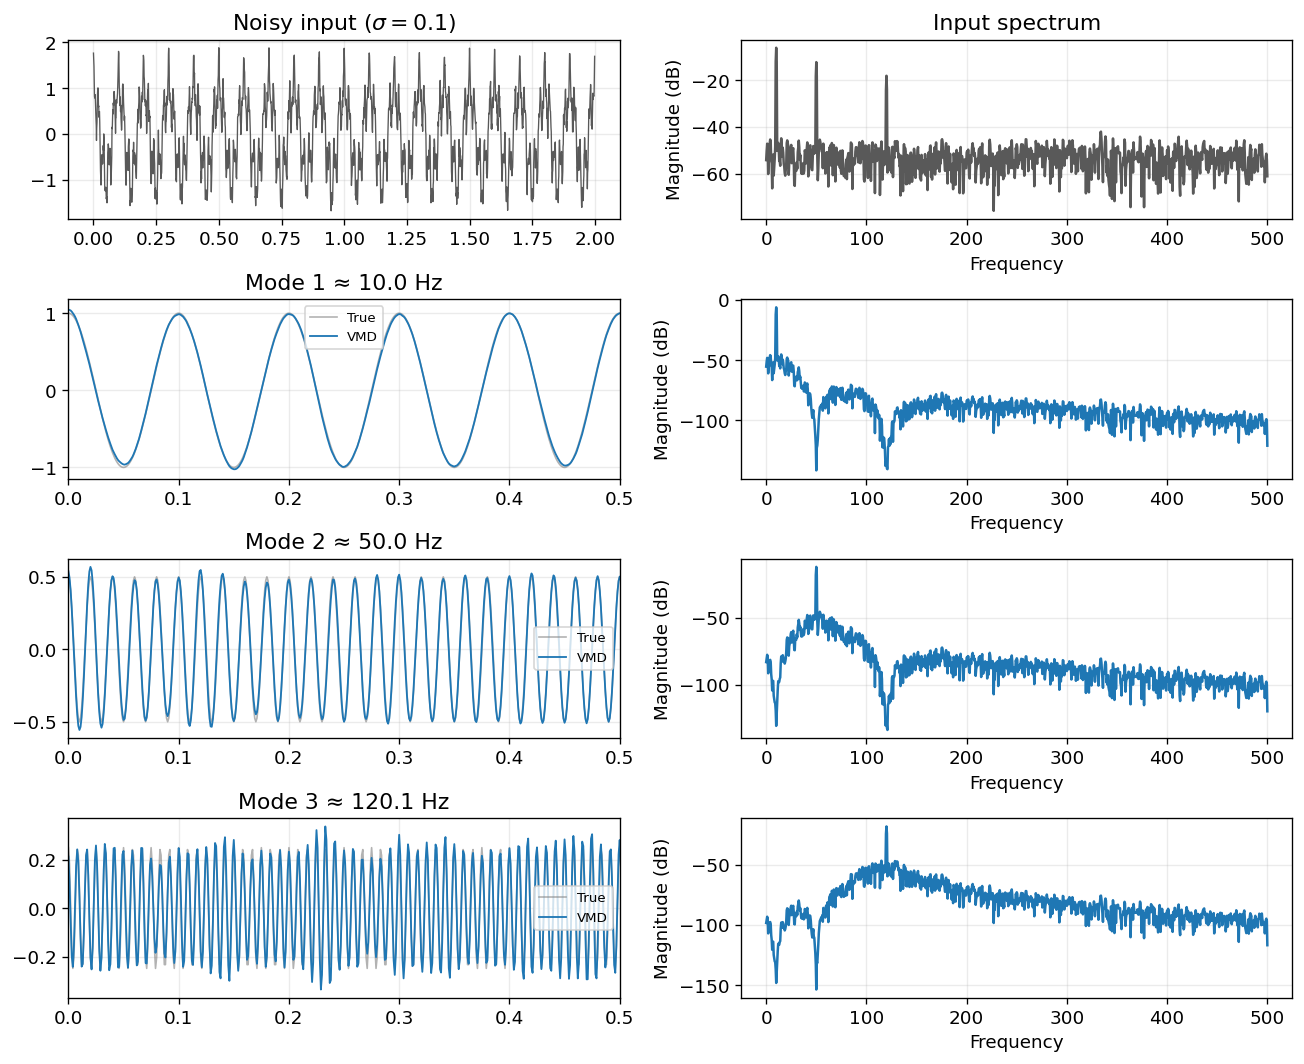

mode1 RE = 0.0302
mode2 RE = 0.0761
mode3 RE = 0.1690


In [ ]:
fs = 1000.0
t = np.arange(0, 2.0, 1 / fs)  # a longer record helps low-frequency estimation
f1, f2, f3 = 10.0, 50.0, 120.0
true = [
    np.cos(2 * np.pi * f1 * t),
    0.5 * np.cos(2 * np.pi * f2 * t),
    0.25 * np.cos(2 * np.pi * f3 * t),
]
rng = np.random.default_rng(0)
sigma = 0.10
signal = np.sum(true, axis=0) + sigma * rng.standard_normal(t.size)

# Under noise: tau=0; choose a moderate alpha so weak harmonics are not lost
vmd = VMD(alpha=1000, K=3, tau=0.0, tol=1e-7, max_iter=500)
modes, _, omega = vmd.fit_transform(signal, return_all=True)
order = np.argsort(omega[-1])
modes = modes[order]
omega_hz = omega[-1][order] * fs

print("Estimated center frequencies [Hz]:", np.round(omega_hz, 2))
print("True center frequencies [Hz]:", [f1, f2, f3])

fig, axs = plt.subplots(4, 2, figsize=(11, 9))
axs[0, 0].plot(t, signal, color="0.35", lw=0.8)
axs[0, 0].set_title(rf"Noisy input ($\sigma={sigma}$)")
axs[0, 1].magnitude_spectrum(signal, Fs=fs, scale="dB", color="0.35")
axs[0, 1].set_title("Input spectrum")

for i in range(3):
    axs[i + 1, 0].plot(t, true[i], color="0.5", lw=1.0, alpha=0.6, label="True")
    axs[i + 1, 0].plot(t, modes[i], lw=1.1, label="VMD")
    axs[i + 1, 0].set_title(f"Mode {i+1} ≈ {omega_hz[i]:.1f} Hz")
    axs[i + 1, 0].legend(fontsize=8)
    axs[i + 1, 0].set_xlim(0, 0.5)
    axs[i + 1, 1].magnitude_spectrum(modes[i], Fs=fs, scale="dB")

plt.tight_layout()
plt.show()

for i in range(3):
    print(f"mode{i+1} RE = {relative_error(true[i], modes[i]):.4f}")

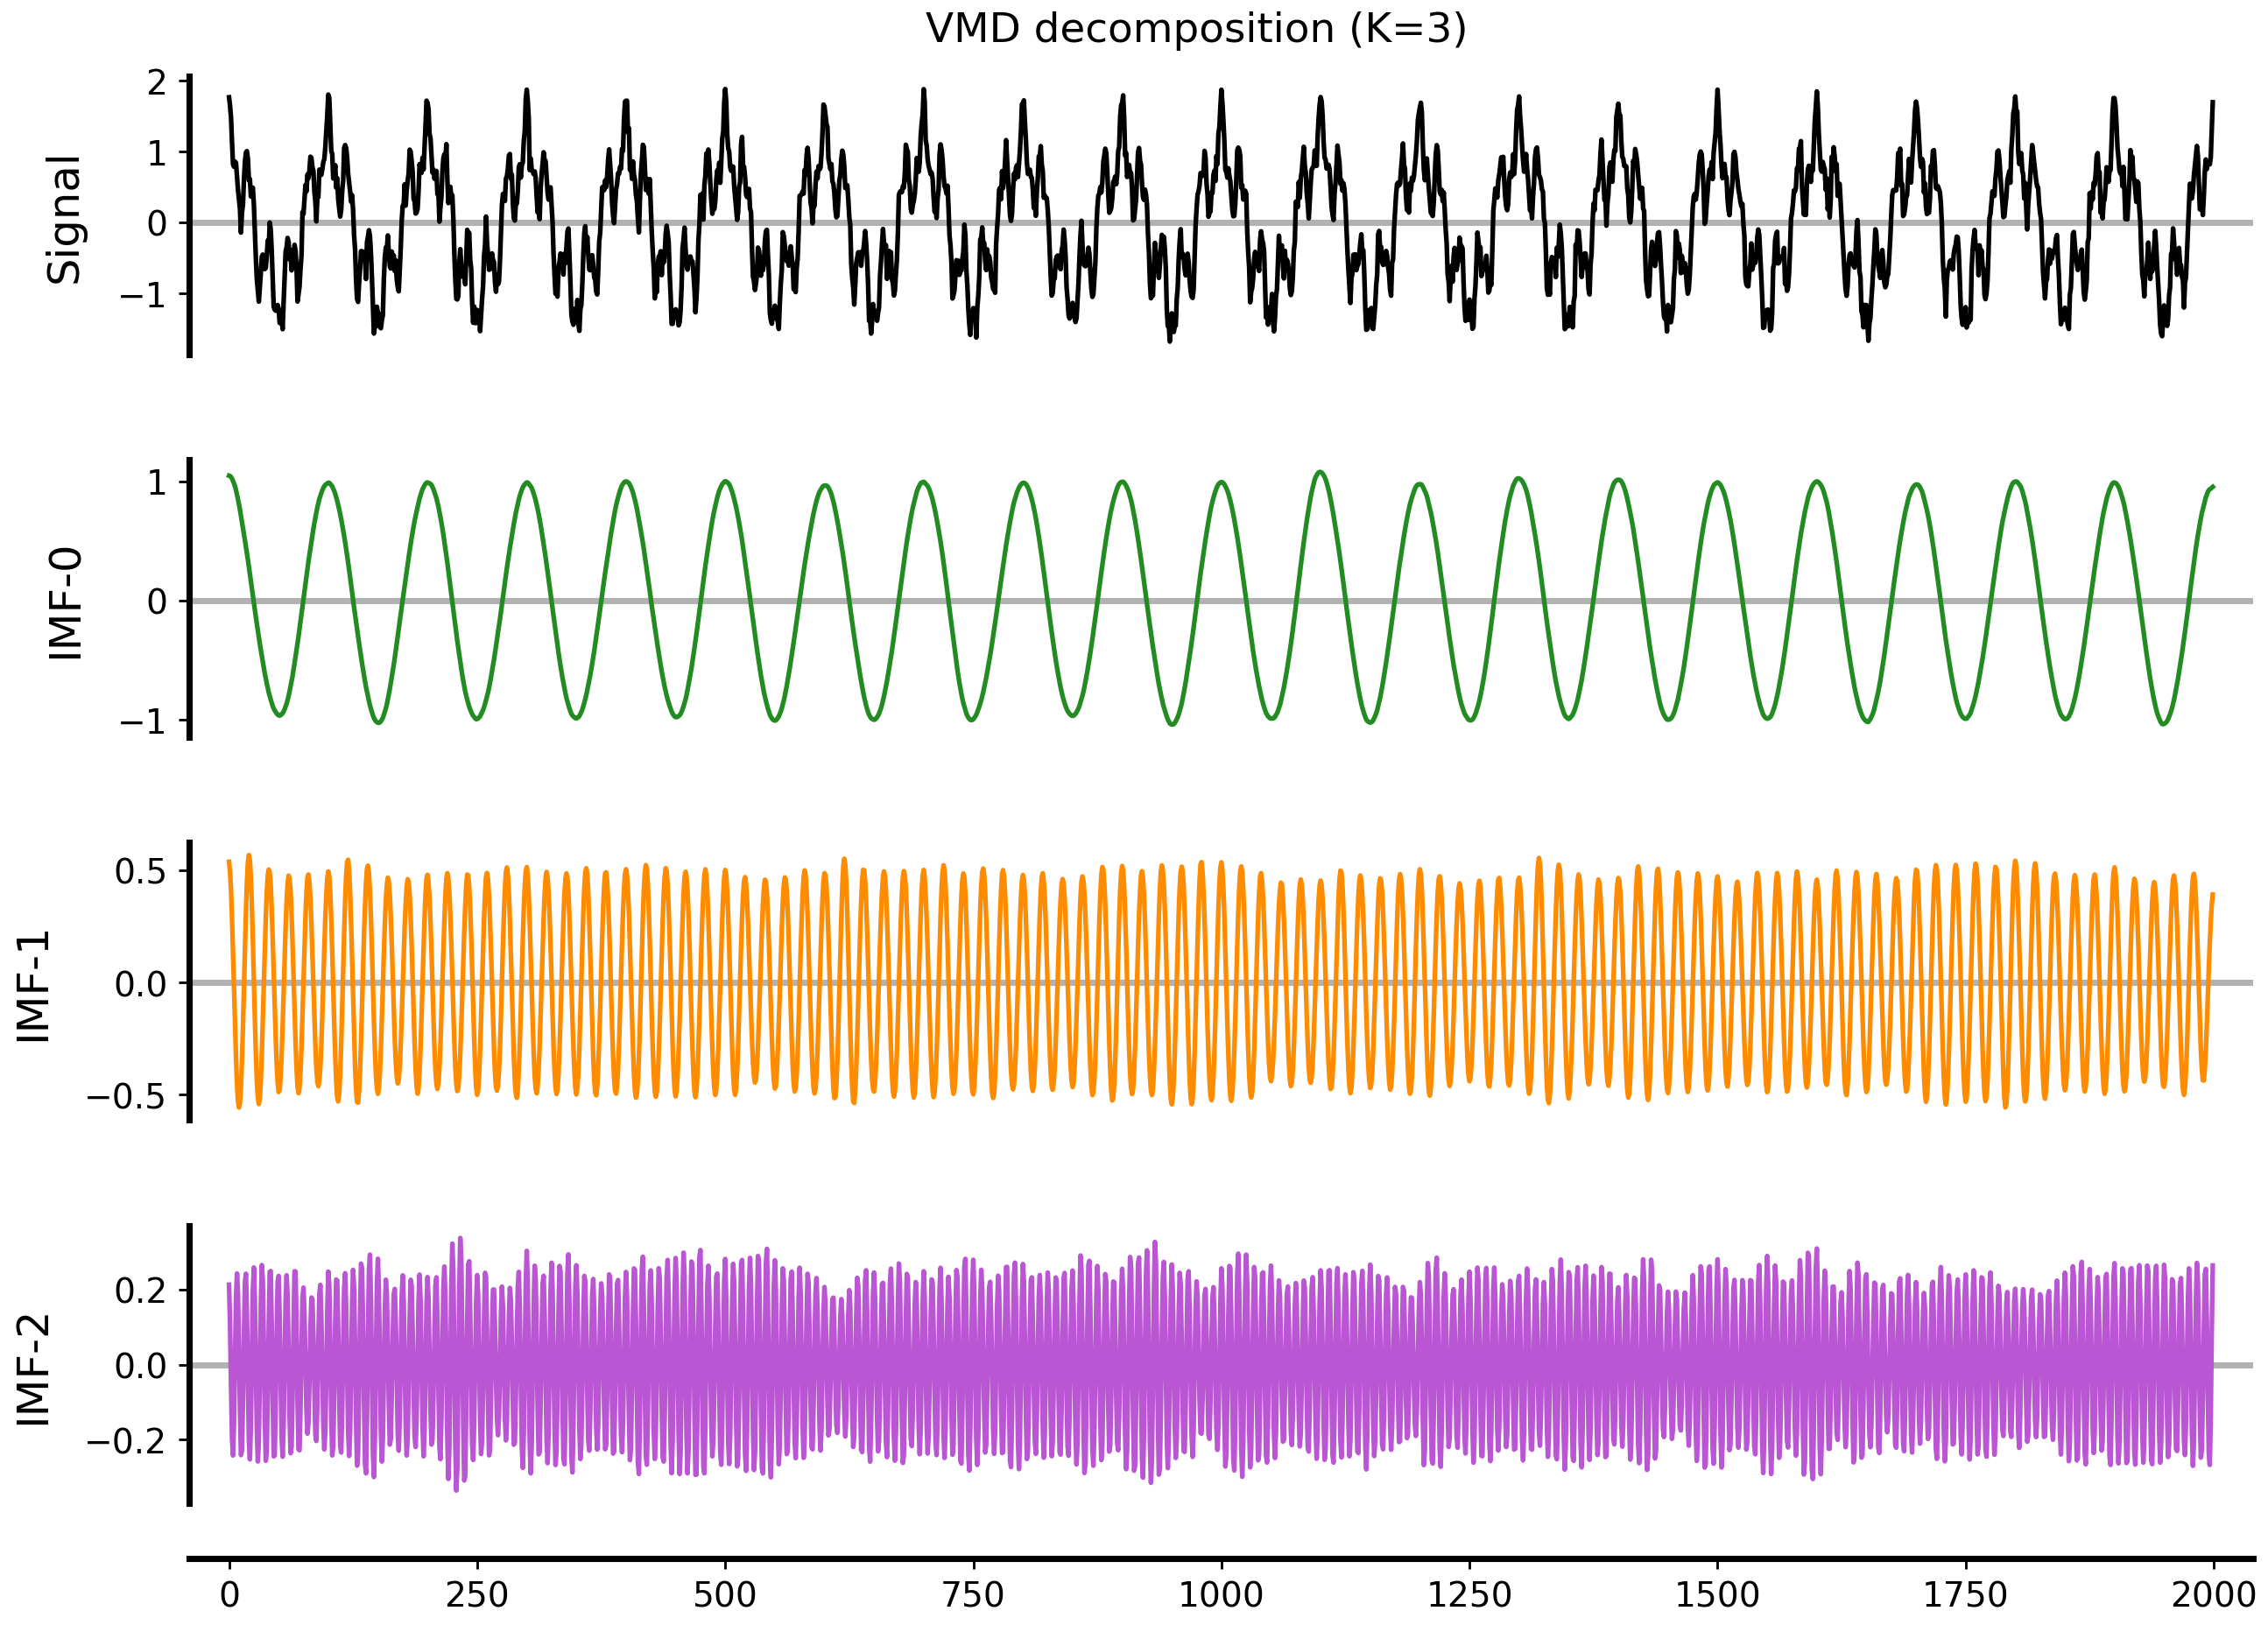

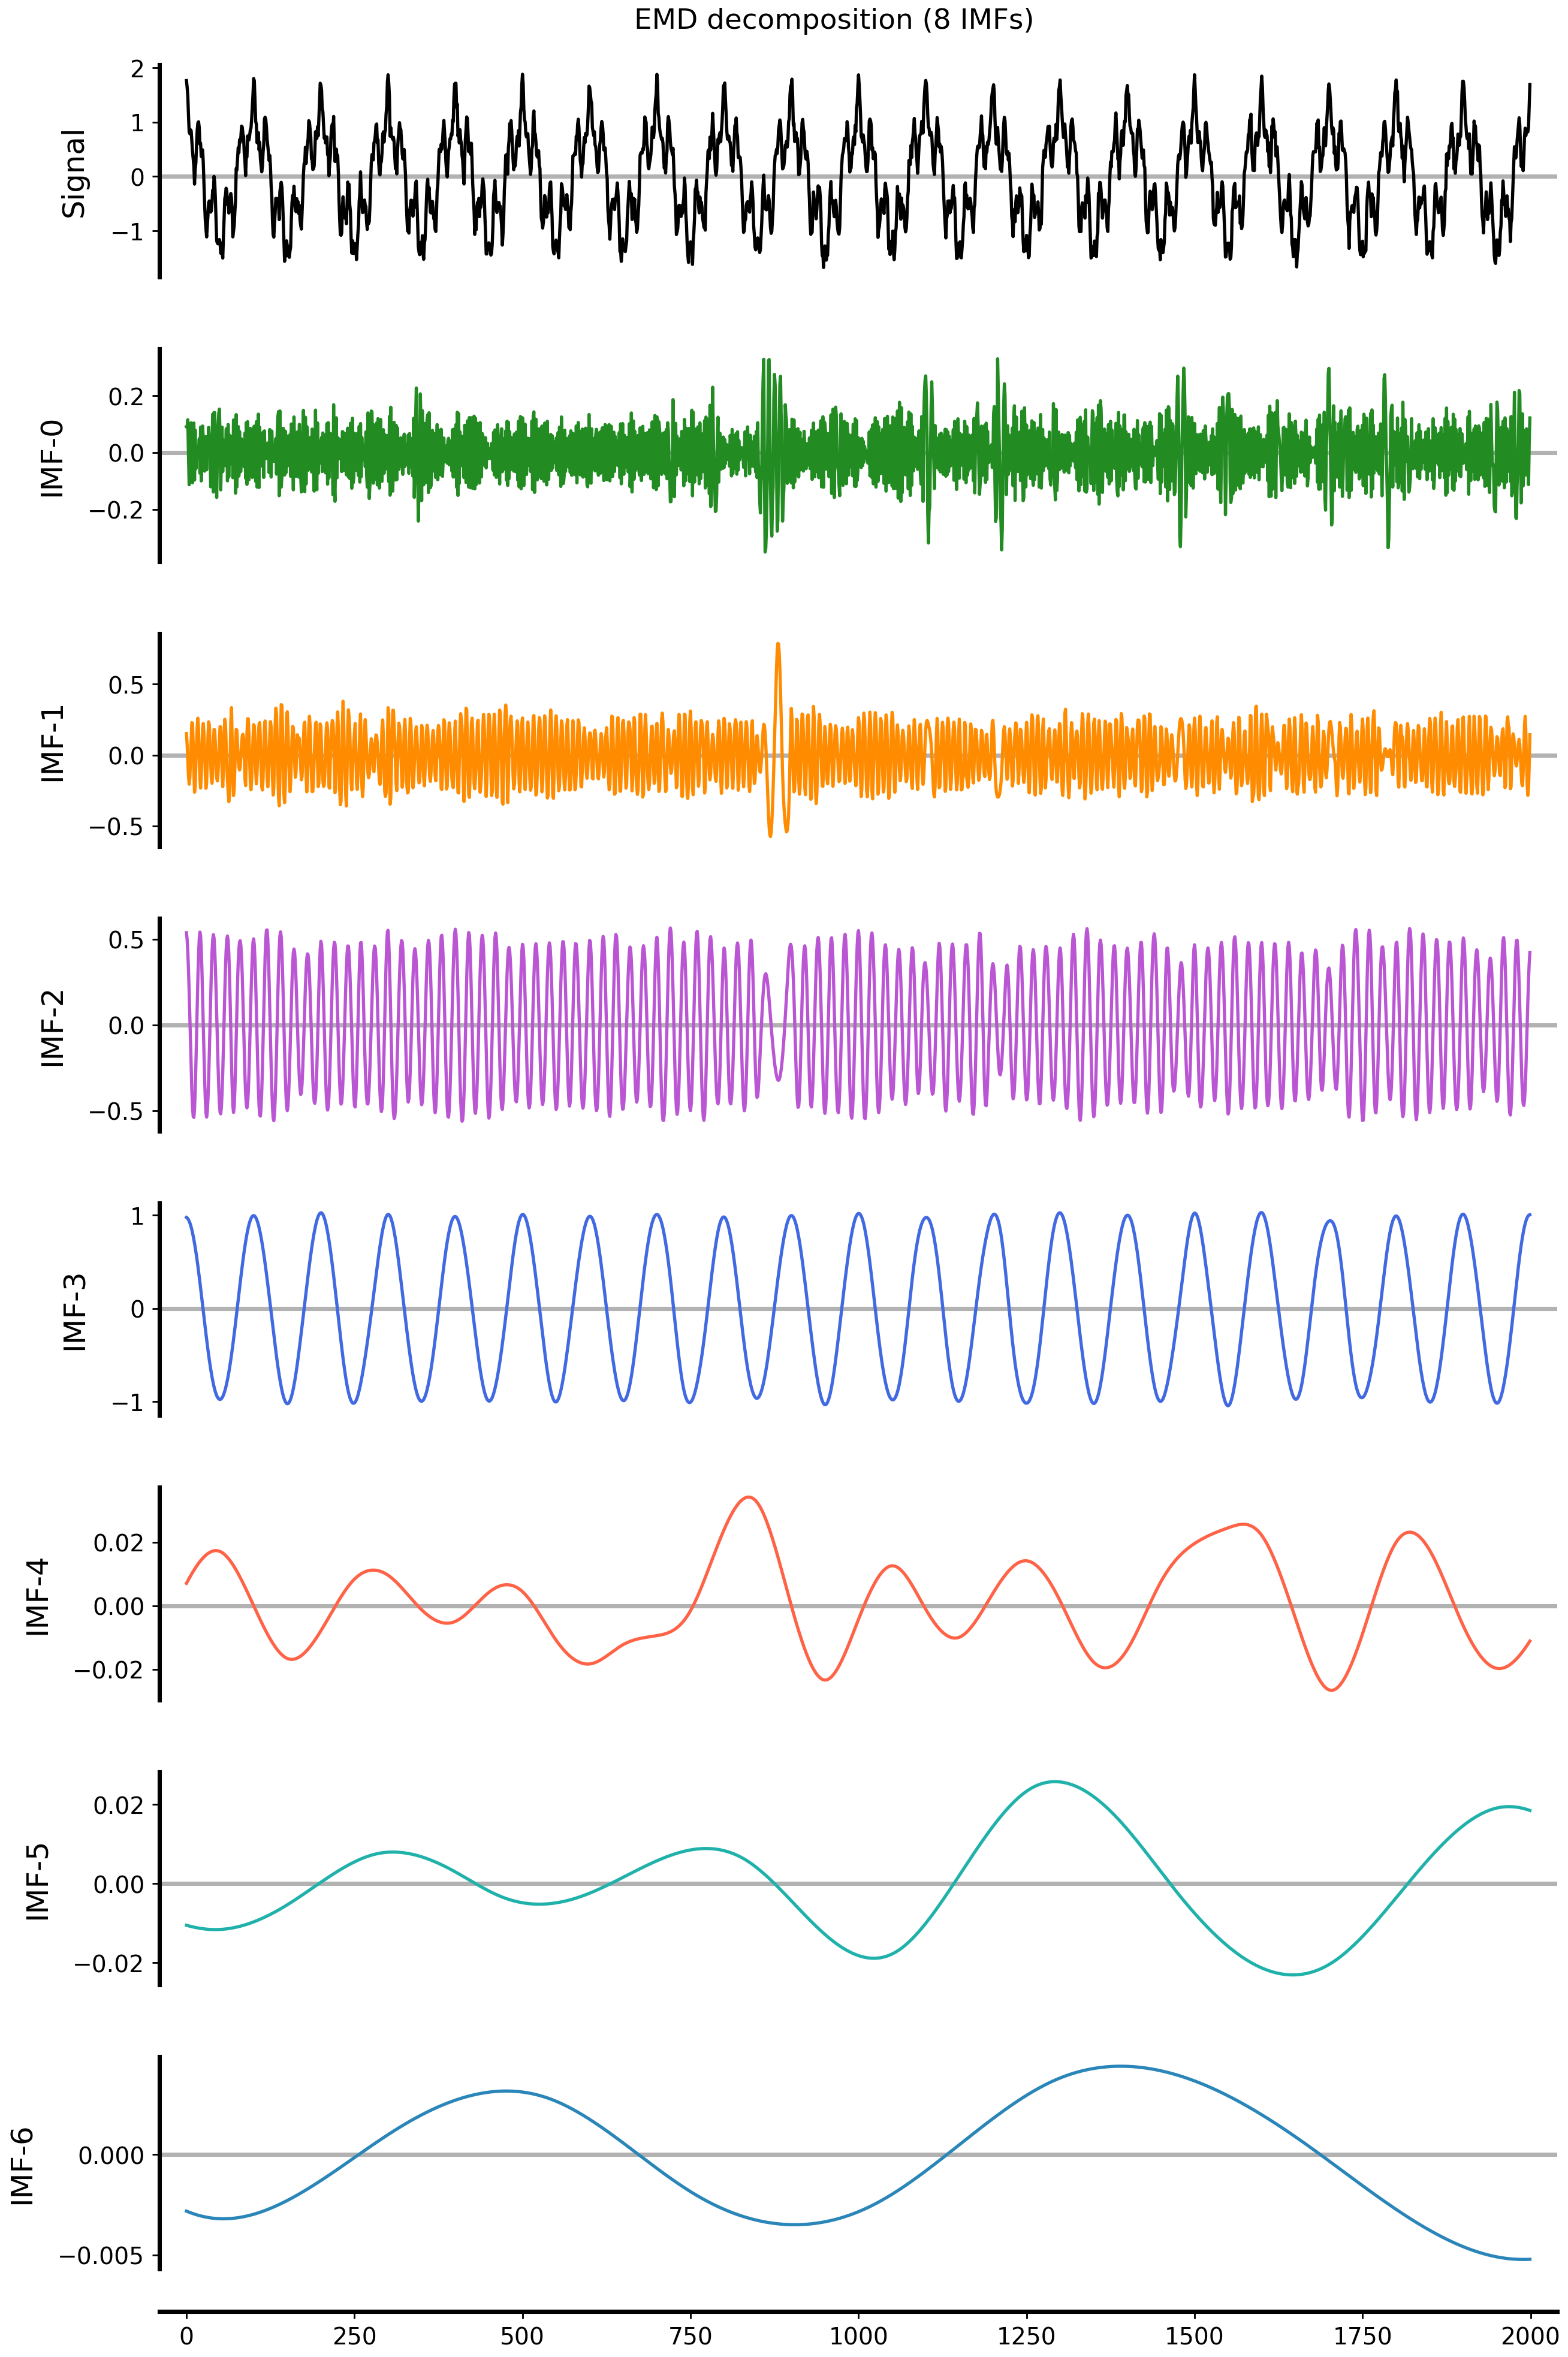

Note: EMD often produces more modes that do not align with pure harmonics; with a prescribed K=3, VMD more readily matches the three true components.


In [7]:
# Compare with EMD on the same noisy tri-harmonic
emd = EMD()
imfs_emd = emd.fit_transform(signal)

fig = plot_IMFs(signal, modes, max_imfs=3, return_figure=True)
fig.suptitle("VMD decomposition (K=3)", y=1.01)
plt.show()

fig = plot_IMFs(
    signal, imfs_emd, max_imfs=min(7, imfs_emd.shape[0]), return_figure=True
)
fig.suptitle(f"EMD decomposition ({imfs_emd.shape[0]} IMFs)", y=1.01)
plt.show()

print(
    "Note: EMD often produces more modes that do not align with pure harmonics; "
    "with a prescribed K=3, VMD more readily matches the three true components."
)

## 9. Experiment 4: Over- / under-segmentation

The number of modes $K$ must be chosen in advance. Paper Fig. 7 discusses:

- **Under-segmentation** ($K$ too small): true components may merge, or a weak component may be discarded as “noise”;
- **Over-segmentation** ($K$ too large): modes may duplicate, or extra modes may absorb noise.

In practice one can diagnose this by checking spectral overlap and whether center frequencies coincide.


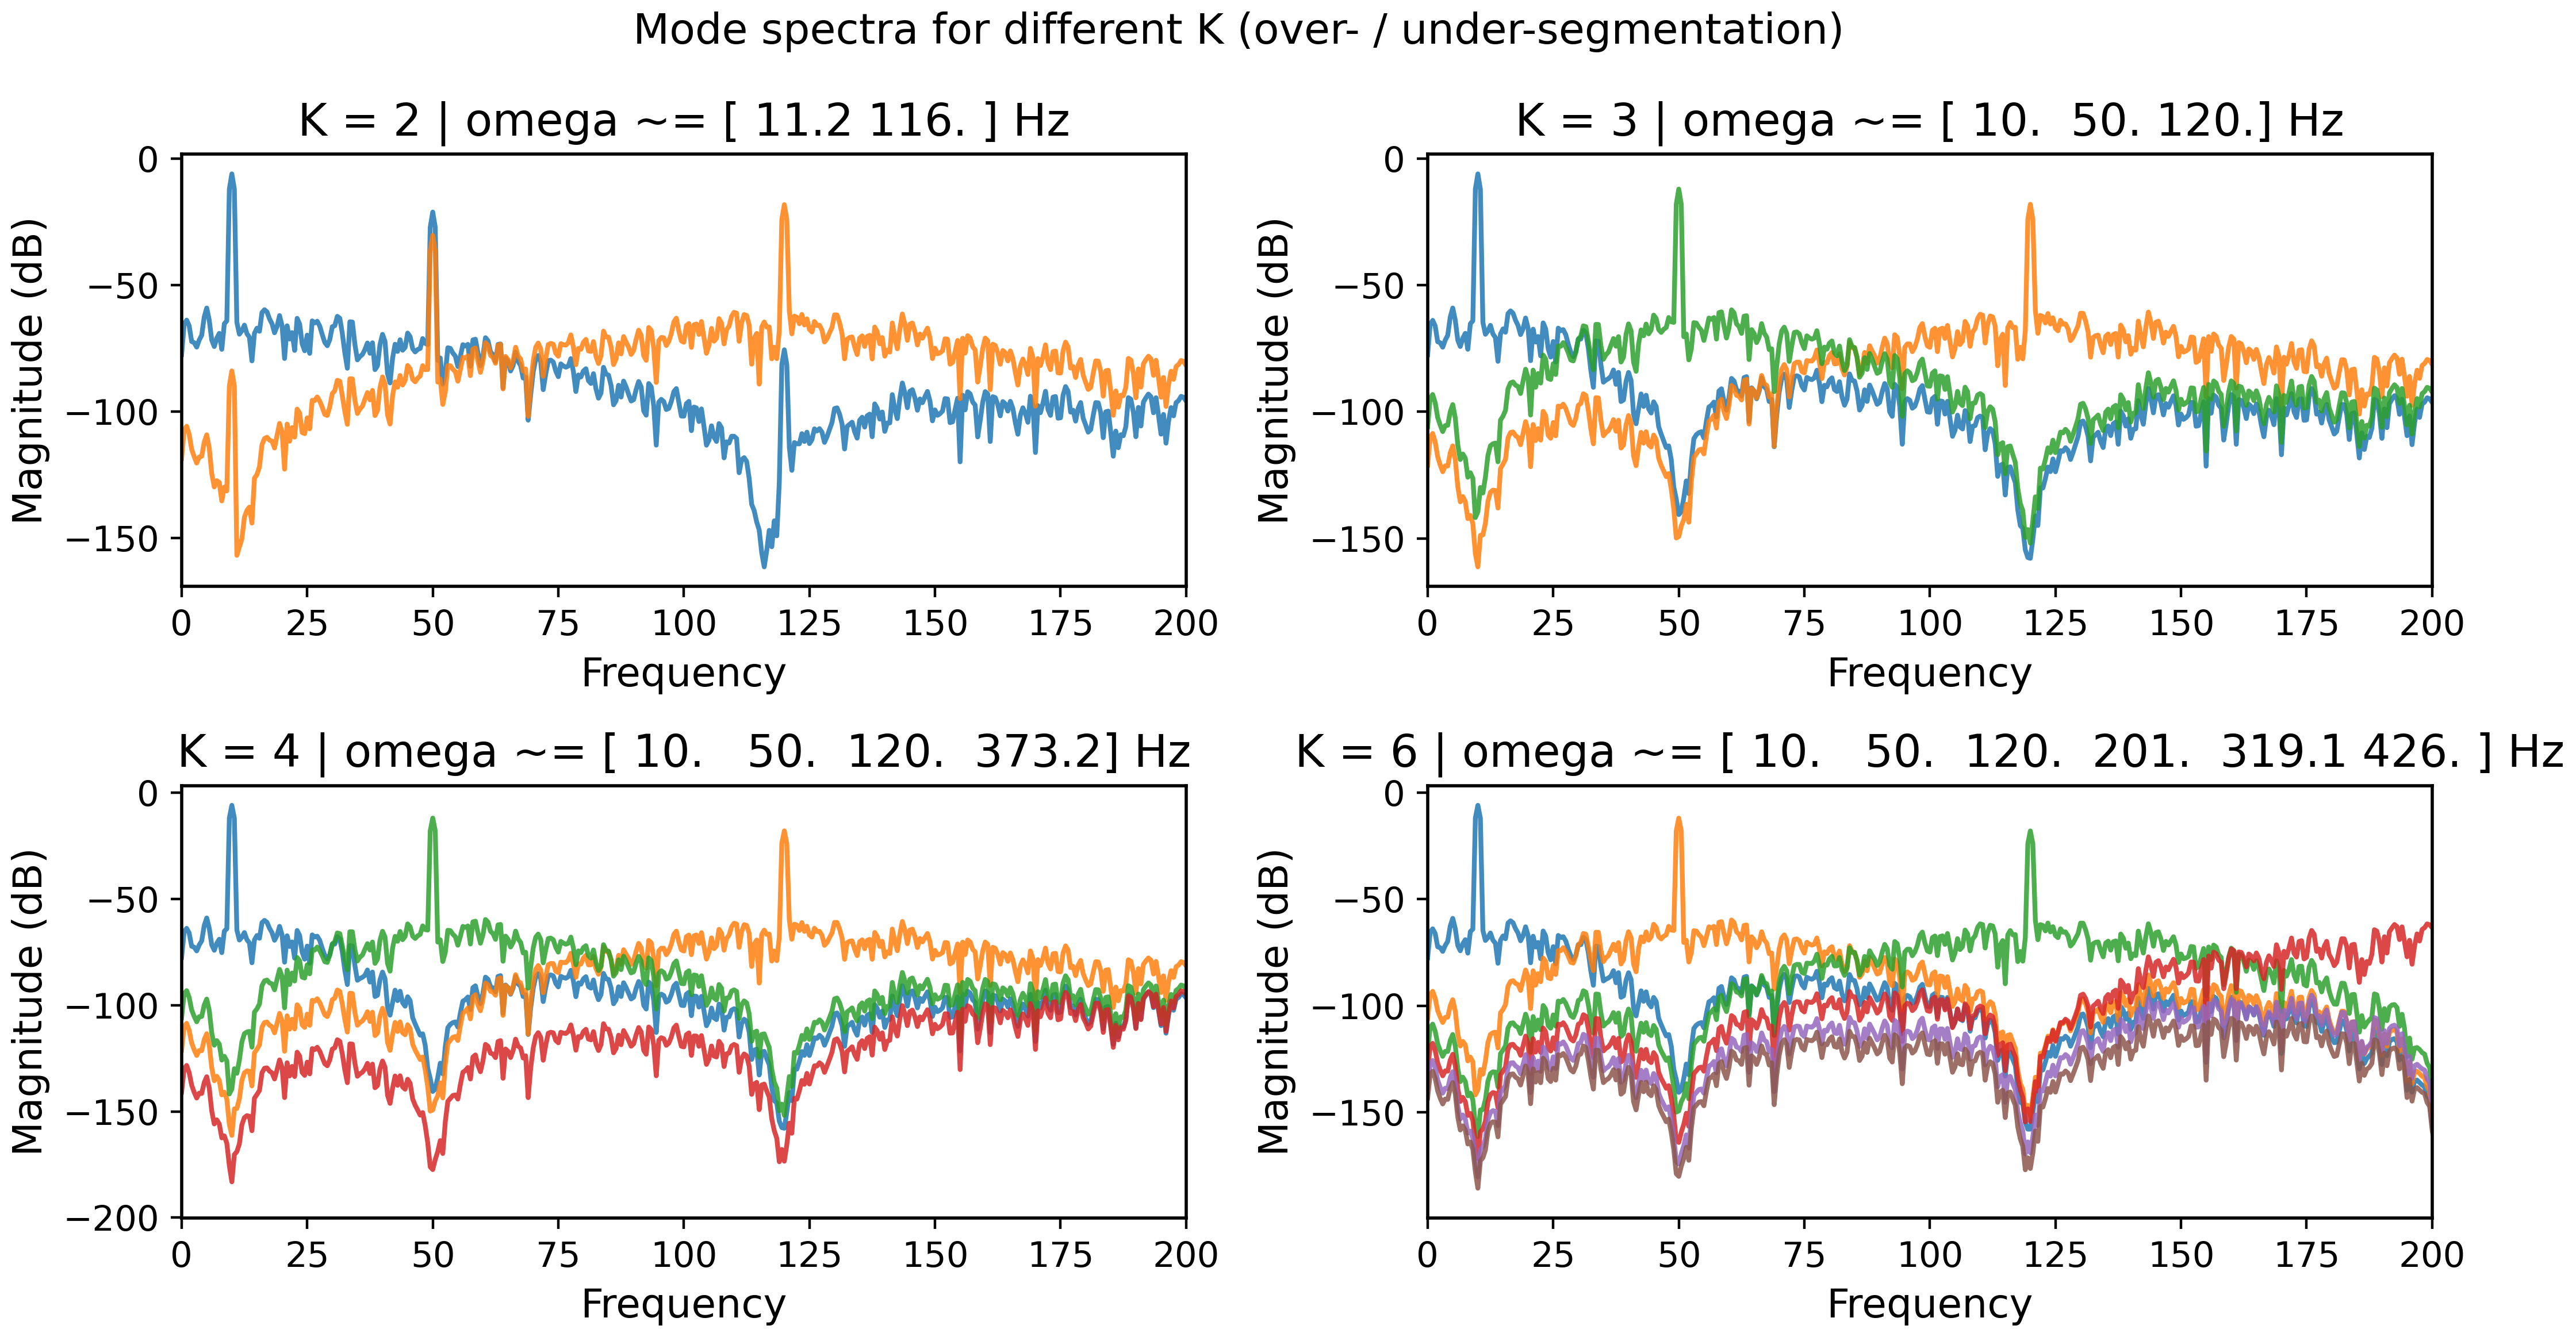

In [8]:
# Cleaner tri-harmonic: inspect spectral allocation for different K
clean = np.sum(true, axis=0) + 0.02 * rng.standard_normal(t.size)

fig, axs = plt.subplots(2, 2, figsize=(11, 6))
for ax, K in zip(axs.ravel(), [2, 3, 4, 6]):
    vmd = VMD(alpha=1000, K=K, tau=0.0, tol=1e-7, max_iter=400)
    modes_k, _, omega_k = vmd.fit_transform(clean, return_all=True)
    for m in modes_k:
        ax.magnitude_spectrum(m, Fs=fs, scale="dB", alpha=0.85)
    cents = np.round(np.sort(omega_k[-1]) * fs, 1)
    ax.set_title(f"K = {K} | omega ~= {cents} Hz")
    ax.set_xlim(0, 200)
plt.suptitle("Mode spectra for different K (over- / under-segmentation)")
plt.tight_layout()
plt.show()

## 10. Experiment 5: Frequency-modulated / non-stationary signals

The paper also notes that if mode spectra overlap strongly over the full record (strong non-stationarity), applying VMD to the entire signal may be suboptimal; short-time segmentation is a natural extension. Even so, for slowly varying FM signals, a suitable $\alpha$ and $K$ often still yield meaningful decompositions.

Below we use PySDKit’s built-in `test_emd` example (chirp + trend).


Final center frequencies (normalized): [0.     0.0153 0.3284]
Relative reconstruction error: 0.05849215336648547


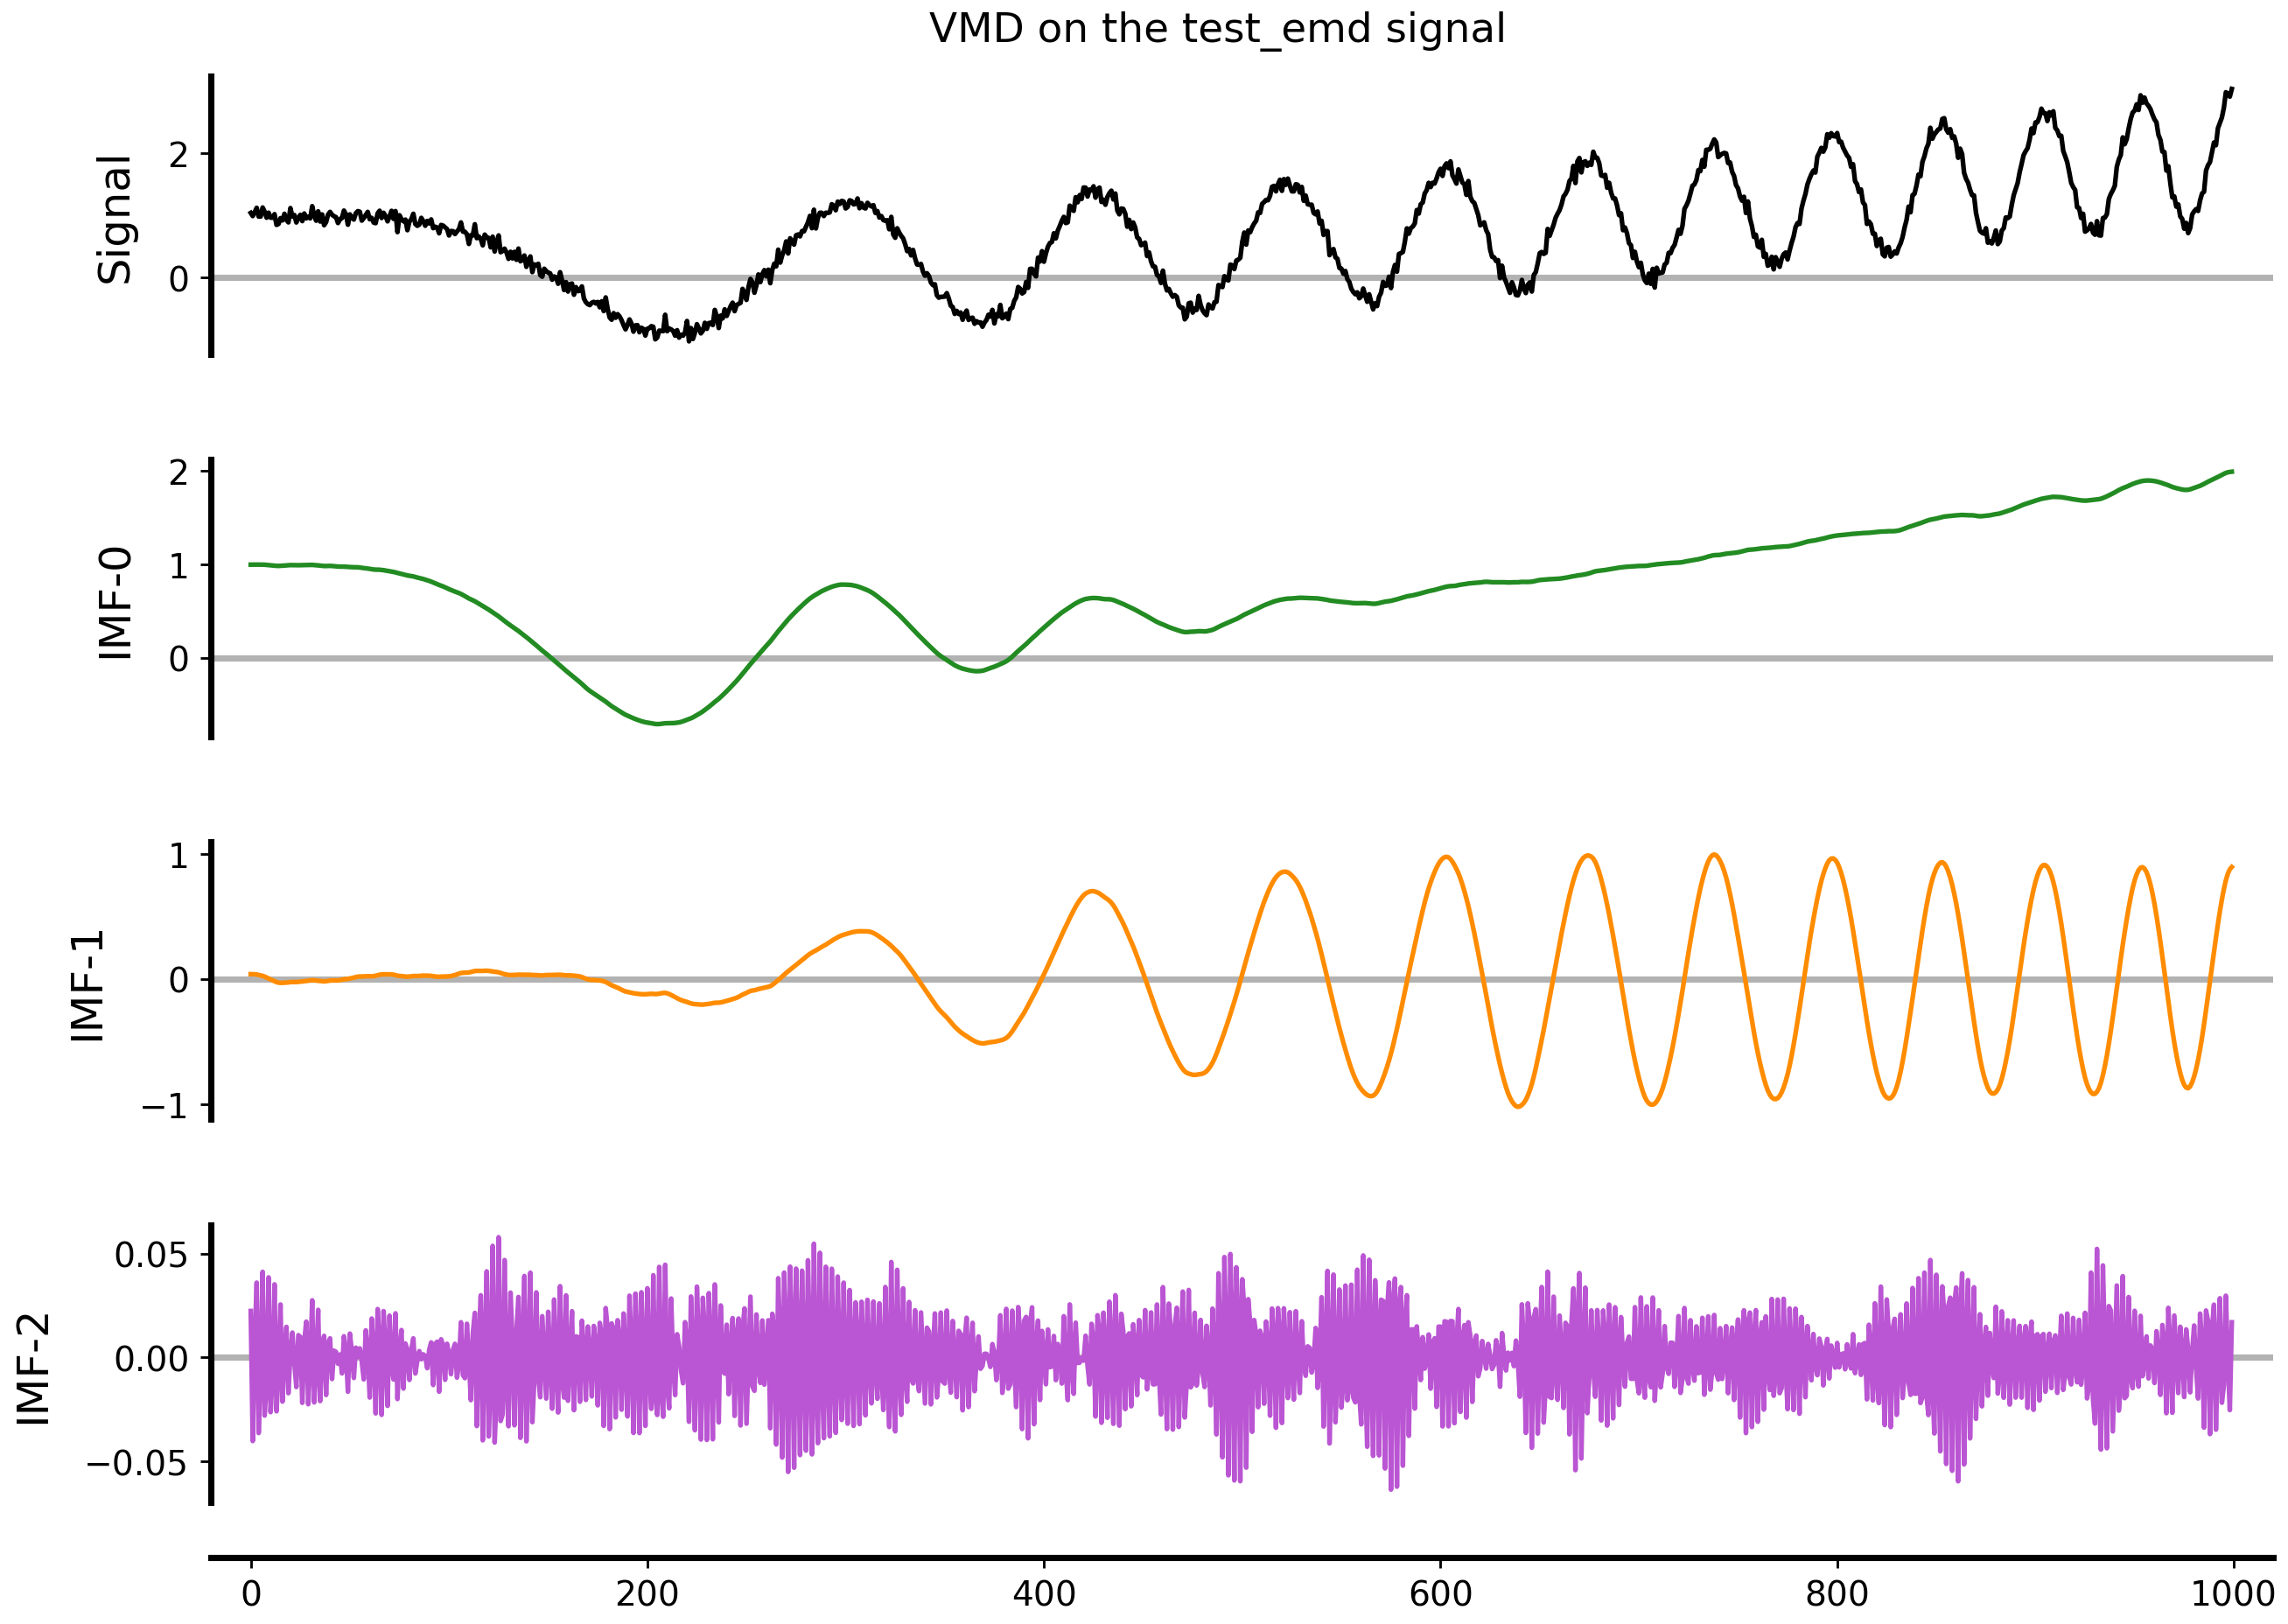

run classic


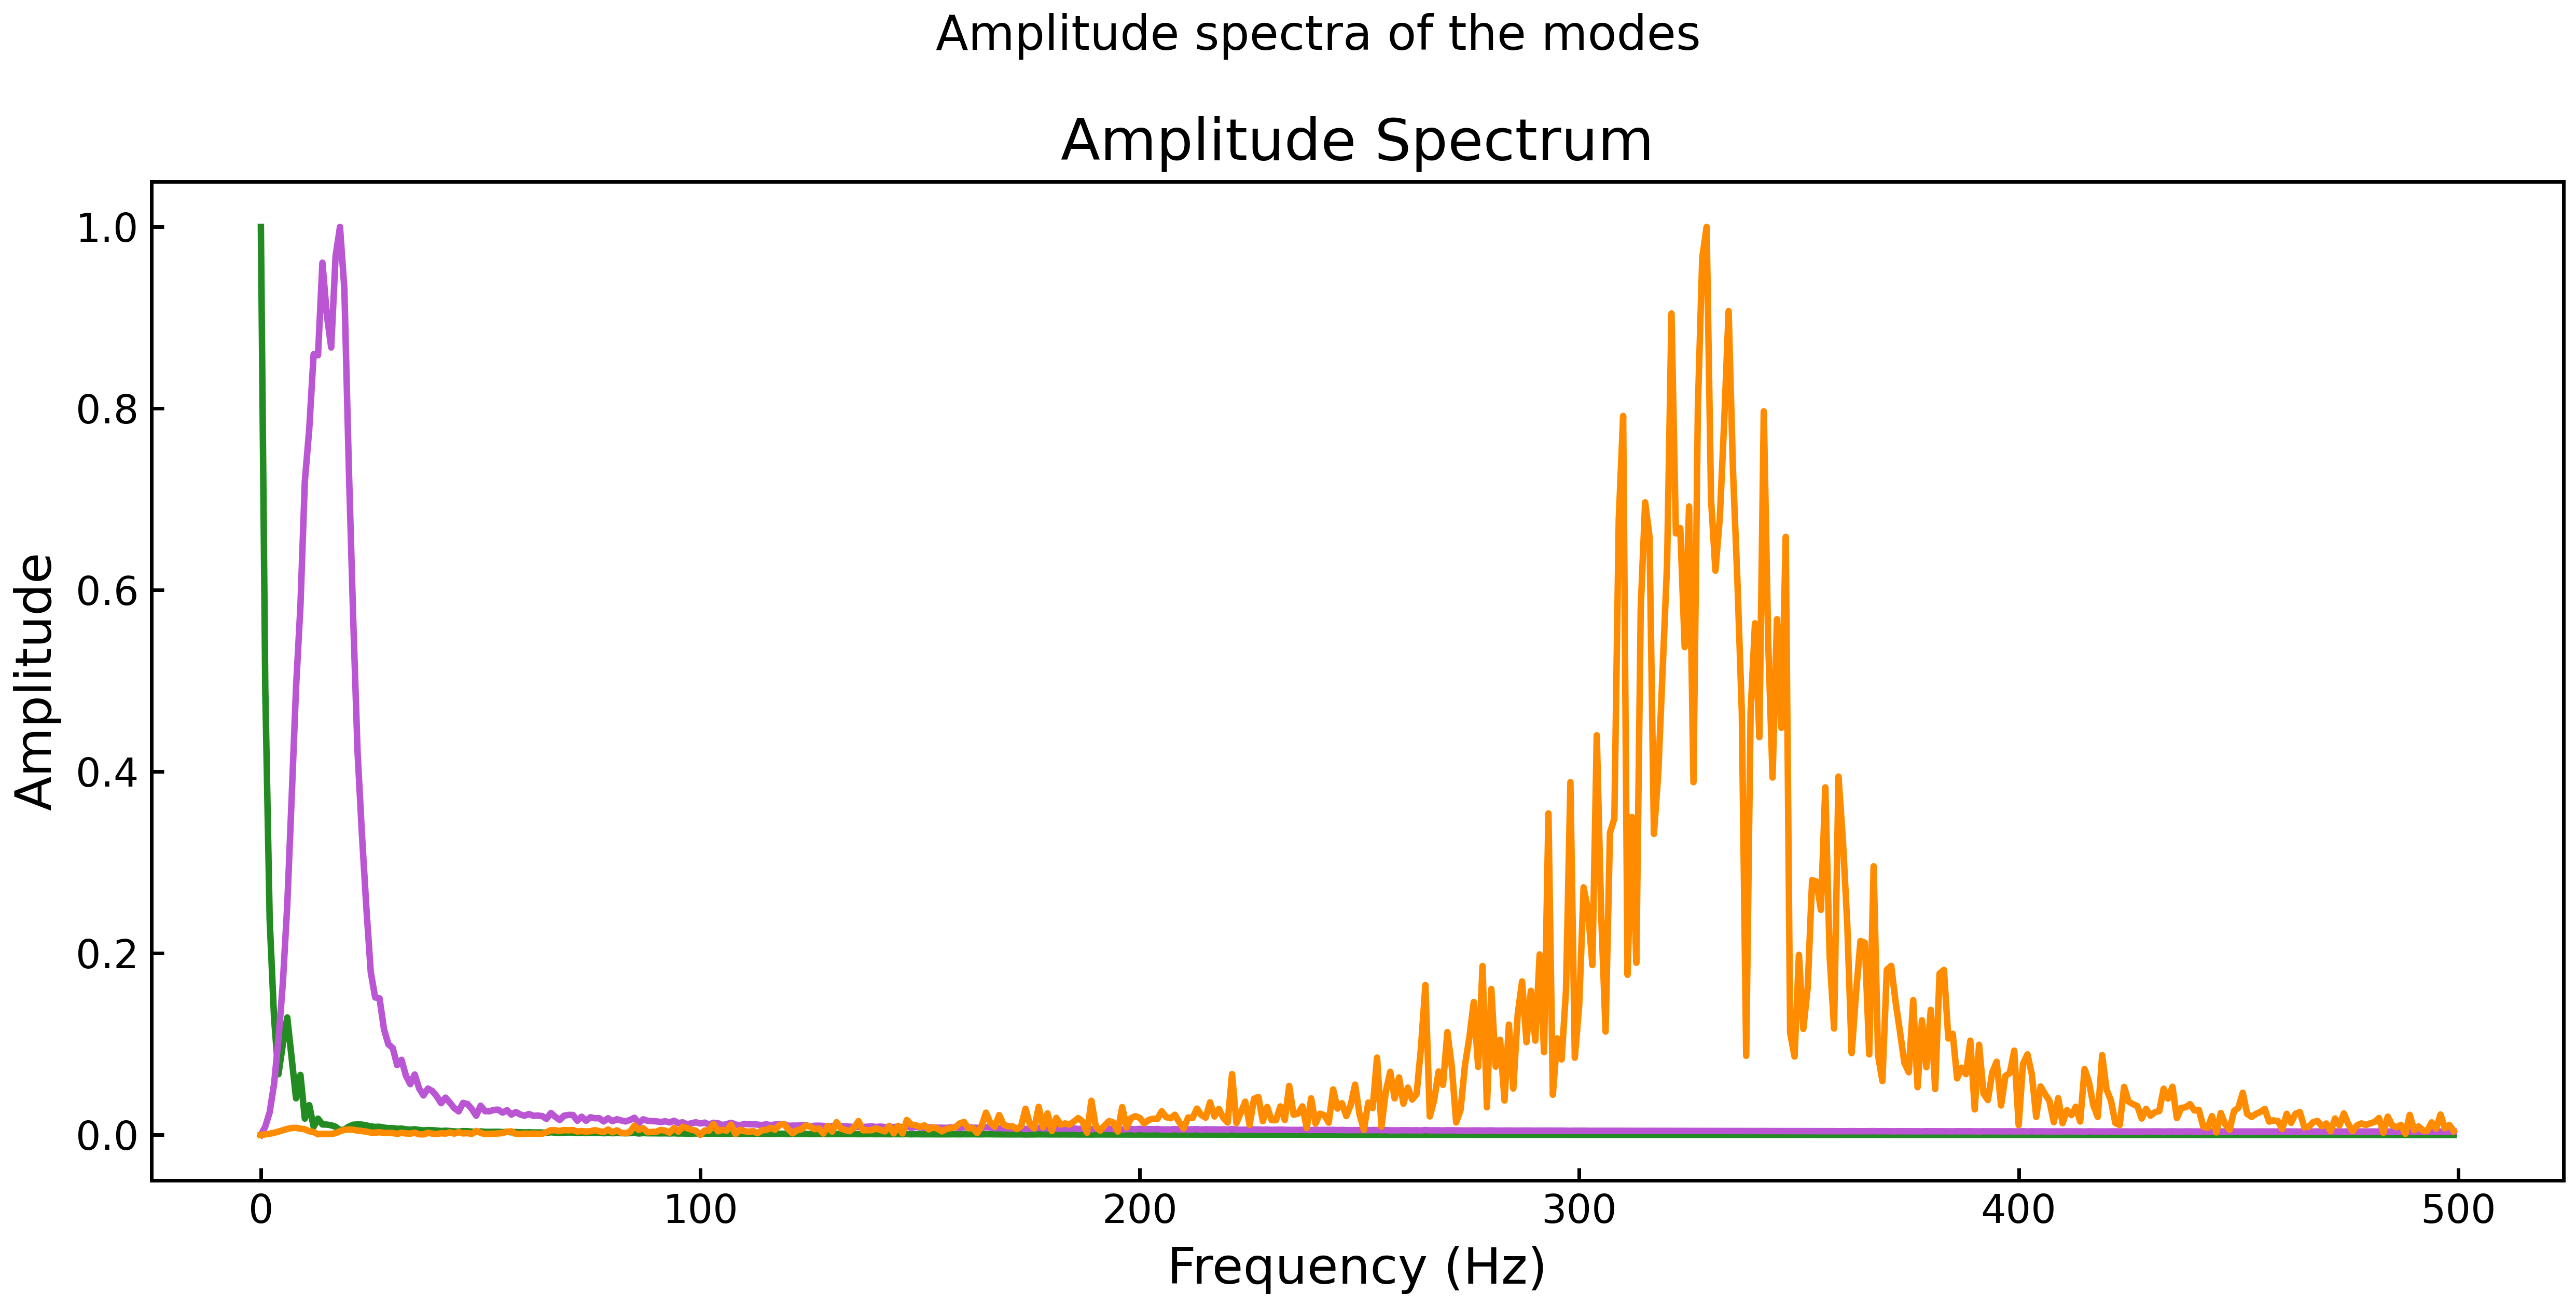

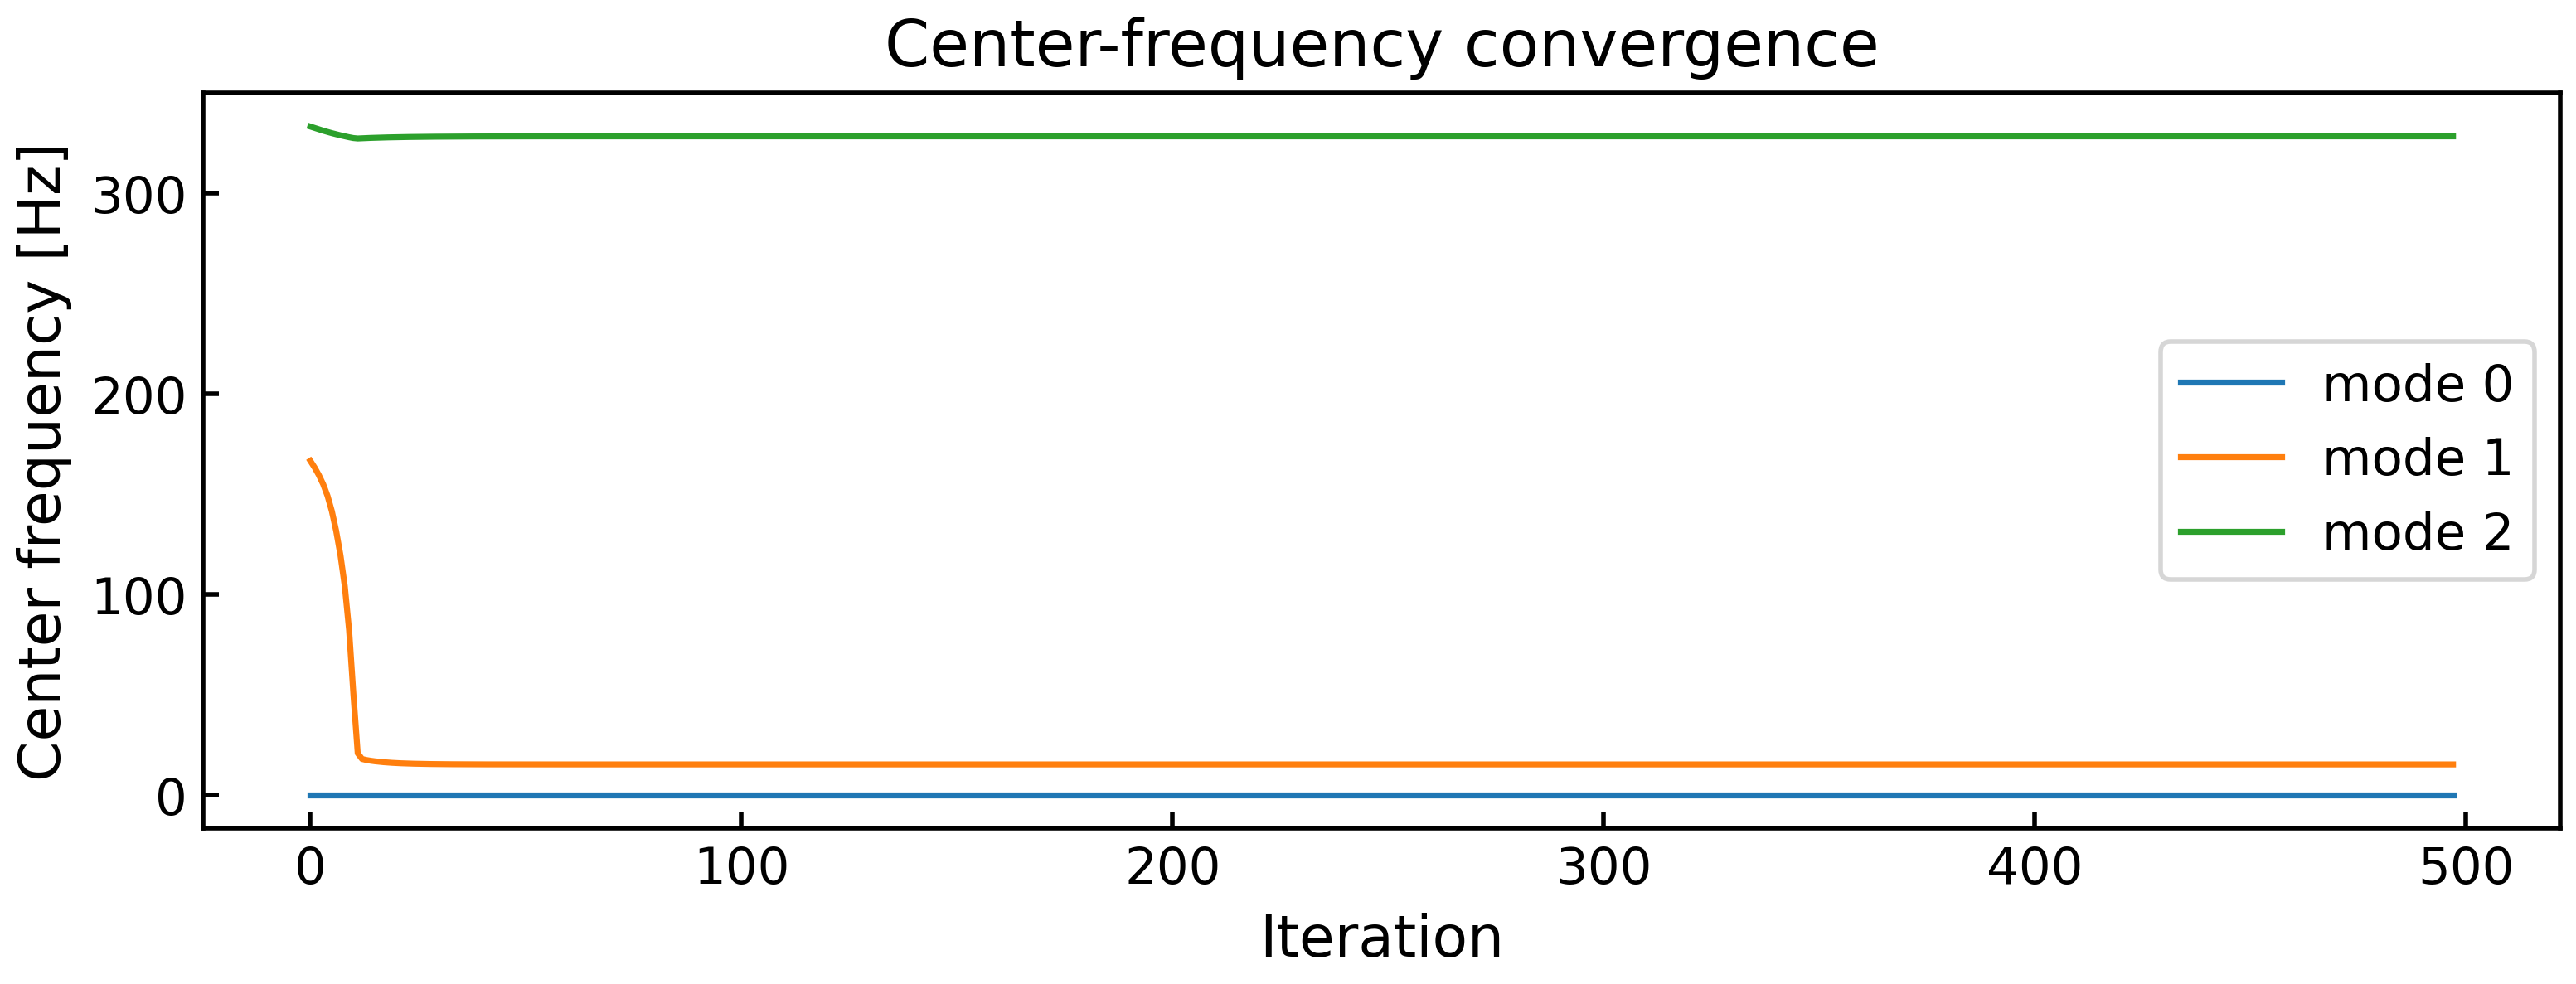

In [9]:
t, signal = test_emd(duration=1.0, sampling_rate=1000, noise_level=0.08)
if signal.size % 2:
    t, signal = t[:-1], signal[:-1]

vmd = VMD(alpha=2000, K=3, tau=0.0, DC=True, tol=1e-7, max_iter=500)
modes, u_hat, omega = vmd.fit_transform(signal, return_all=True)

print("Final center frequencies (normalized):", np.round(omega[-1], 4))
print("Relative reconstruction error:", relative_error(signal, modes.sum(0)))

fig = plot_IMFs(signal, modes, return_figure=True)
fig.suptitle("VMD on the test_emd signal", y=1.01)
plt.show()

fig = plot_IMFs_amplitude_spectra(modes, return_figure=True)
fig.suptitle("Amplitude spectra of the modes", y=1.01)
plt.show()

# Center-frequency trajectories over ADMM iterations
fig, ax = plt.subplots(figsize=(8, 3.2))
n_iter = omega.shape[0]
for k in range(omega.shape[1]):
    ax.plot(np.arange(n_iter), omega[:, k] * 1000.0, lw=1.3, label=f"mode {k}")
ax.set_xlabel("Iteration")
ax.set_ylabel("Center frequency [Hz]")
ax.set_title("Center-frequency convergence")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Summary

1. **Historical significance**: Before VMD, leading adaptive decompositions (notably EMD) were empirically useful but lacked a provable variational / optimization formulation. VMD casts decomposition as a constrained variational problem and solves it with ADMM.
2. **Core idea**: A mode is a narrow-band component around an adaptive center frequency; bandwidth is measured by the smoothness of the Hilbert-demodulated signal.
3. **Algorithmic structure**: Fourier-domain Wiener update of modes → power-spectrum center-of-gravity update of $\omega_k$ → dual ascent for $\lambda$.
4. **Practical tips**:
   - Choose $K$ from prior knowledge or validation;
   - $\alpha$ controls bandwidth;
   - Prefer $\tau=0$ under strong noise;
   - Mirror extension mitigates boundary effects;
   - For strongly non-stationary data, consider short-time VMD / STVMD.

### Further reading

- Dragomiretskiy & Zosso, *IEEE TSP*, 2014 (this paper)
- Huang et al., *Proc. R. Soc. Lond. A*, 1998 (EMD / HHT)
- Rehman & Aftab, *IEEE TSP*, 2019 (MVMD)
- Jia et al., *Signal Processing*, 2026 (STVMD)

### One-liner with PySDKit

    from pysdkit import VMD
    modes = VMD(alpha=2000, K=3, tau=0.0).fit_transform(signal)
